# Extract Belief-Change Conversations from WildChat

This notebook identifies conversations showing belief/intent changes, aligned with the methodology from
**"On the Predictability of Human Conversation"** (ICML 2026 submission).

## Paper's Core Methodology

Based on `compute_ce_fsdp_normalize_recurrent.py`:

1. **Token-level exploitation**: For each token in target utterance, check if it appeared in history (prefix)
2. **`seen_in_prefix`**: Binary indicator per token (1 if token appeared in history, 0 otherwise)
3. **`K_token`**: Distance (in tokens) from current position to last occurrence in history
4. **`K_round`**: Distance (in conversation rounds) to last occurrence
5. **History construction**: Uses `history_round_len` rounds before target utterance
6. **User filtering**: `round_threshold=30` means users with 60+ turns (30 rounds × 2 turns/round)

## Our Adaptation

We use their exploitation tracking to identify:
- **Predictable users**: High exploitation rate (most tokens seen before)
- **Unpredictable users**: Low exploitation rate (many novel tokens) → more likely to show belief changes

In [ ]:
# Install dependencies
# !pip install datasets numpy scipy transformers

In [1]:
import re #datetime
import json
import bisect
from collections import defaultdict
from dataclasses import dataclass, asdict, field
from datasets import load_dataset
from typing import Generator
import numpy as np
from scipy.optimize import curve_fit
from transformers import AutoTokenizer

/lambda/nfs/simulate-user-persona/persona-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from datetime import datetime as dt
import numpy as np

# Custom JSON encoder to handle datetime and numpy types
class CustomJSONEncoder(json.JSONEncoder):
    def default(self, obj):
        # Handle datetime
        if hasattr(obj, 'isoformat'):
            return obj.isoformat()
        # Handle numpy types
        if isinstance(obj, (np.integer, np.int64, np.int32)):
            return int(obj)
        if isinstance(obj, (np.floating, np.float64, np.float32)):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.bool_):
            return bool(obj)
        return super().default(obj)

def json_dumps(obj):
    """JSON dumps with custom encoder for datetime/numpy."""
    return json.dumps(obj, cls=CustomJSONEncoder)

## Configuration

Parameters aligned with paper's defaults from `compute_ce_fsdp_normalize_recurrent.py`

In [16]:
# === Paper-aligned settings ===
ROUND_THRESHOLD = 30              # Paper default: users with 30+ rounds (60+ turns)
MAX_CONVERSATIONS = 100         # Number of conversations to scan
MAX_ITEM_PER_USER = 10            # Paper default: max utterances to analyze per user
MAX_ASSISTANT_SEQ_LEN = 100       # Paper default: truncate assistant responses
LANGUAGE = "English"              # Paper default: filter by language

# === Tokenizer (paper uses Qwen2.5) ===
USE_LLM_TOKENIZER = True         # Set True to use actual LLM tokenizer (slower but more accurate)
TOKENIZER_NAME = "Qwen/Qwen2.5-0.5B"  # Paper's default model

# === Output settings ===
OUTPUT_FILE = "belief_change_candidates_llm.jsonl"
USER_STATS_FILE = "user_exploitation_stats_llm.jsonl"
GENERATE_LLM_REVIEW = True

## Data Structures

In [17]:
@dataclass
class UserProfile:
    """Aggregated user data following paper's methodology."""
    user_id: str
    conversations: list = field(default_factory=list)
    total_rounds: int = 0
    
    # Exploitation metrics (per-utterance)
    exploitation_rates: list = field(default_factory=list)  # seen_count / total_tokens per utterance
    k_token_means: list = field(default_factory=list)       # mean K_token per utterance
    k_round_means: list = field(default_factory=list)       # mean K_round per utterance
    
    # Scaling law parameters
    p1: float = None
    alpha: float = None
    
    # Classification
    predictability_type: str = None  # "high", "medium", "low"


@dataclass
class CandidateConversation:
    """Conversation with belief change signals."""
    conversation_id: str
    user_id: str
    turns: list
    detection_method: str
    matched_patterns: list
    change_turn_indices: list
    
    # Paper metrics
    user_p1: float = None
    user_alpha: float = None
    user_predictability: str = None
    exploitation_at_change: float = None

## Paper's Core Functions (Adapted)

These functions are adapted directly from `compute_ce_fsdp_normalize_recurrent.py`

In [18]:
# Initialize tokenizer (optional - for exact paper alignment)
if USE_LLM_TOKENIZER:
    print(f"Loading tokenizer: {TOKENIZER_NAME}")
    tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME, trust_remote_code=True)
else:
    tokenizer = None
    print("Using word-level tokenization (faster, slightly less accurate)")

Loading tokenizer: Qwen/Qwen2.5-0.5B


In [19]:
def tokenize_text(text: str, use_llm: bool = False) -> list:
    """
    Tokenize text. Paper uses LLM tokenizer but bag-of-words approximation is acceptable.
    """
    if use_llm and tokenizer is not None:
        return tokenizer(text, add_special_tokens=False).input_ids
    else:
        # Word-level tokenization (paper's Eq. 4 approximation)
        words = re.findall(r'\b\w+\b', text.lower())
        return words


def fix_conversation(conversation: list) -> list:
    """
    Paper's conversation fixing logic (lines 135-146):
    - Remove leading assistant messages
    - Merge consecutive same-role messages
    """
    convs = conversation.copy()
    
    # Remove leading assistant messages
    while convs and convs[0].get("role") in ["assistant", "gpt"]:
        convs.pop(0)
    
    # Merge duplicate roles
    fixed = []
    for c in convs:
        if not fixed or c.get("role") != fixed[-1].get("role"):
            fixed.append(c.copy())
        else:
            fixed[-1]["content"] = fixed[-1].get("content", "") + " " + c.get("content", "")
    
    return fixed


def build_prefix_and_boundaries(
    history: list, 
    current_role: str,
    max_assistant_seq_len: int = 100
) -> tuple:
    """
    Paper's build_prefix_and_boundaries function (lines 22-50, 106-127).
    
    Builds:
    - prefix_tokens: All tokens in history + prompt
    - round_end_exclusive: Indices marking end of each assistant turn
    """
    header = ("Here is a conversation between a user and an AI assistant. "
              "The user asks questions, and the AI provides answers.\n\n")
    
    prefix_tokens = tokenize_text(header, USE_LLM_TOKENIZER)
    round_end_exclusive = []
    
    for row in history:
        content = row.get("content", "").replace("\n", " ").strip()
        role = row.get("role", "")
        
        # Truncate assistant responses (paper line 38-39)
        if role in ["gpt", "assistant"] and len(content) > max_assistant_seq_len:
            content = content[:max_assistant_seq_len] + "..."
        
        piece = f'{role}:\n{content}\n\n'
        piece_tokens = tokenize_text(piece, USE_LLM_TOKENIZER)
        prefix_tokens.extend(piece_tokens)
        
        # Track end of assistant turns (for K_round calculation)
        if role in ["gpt", "assistant"]:
            round_end_exclusive.append(len(prefix_tokens))
    
    # Add prompt for current role
    prompt_piece = f"{current_role}:\n"
    prefix_tokens.extend(tokenize_text(prompt_piece, USE_LLM_TOKENIZER))
    
    return prefix_tokens, round_end_exclusive


def compute_seen_and_recency(
    prefix_tokens: list,
    target_tokens: list,
    round_end_exclusive: list,
    history_round_len: int
) -> dict:
    """
    Paper's compute_seen_and_recency function (lines 53-95).
    
    For each token in target:
    - seen_in_prefix: 1 if token appeared in prefix, 0 otherwise
    - last_pos_in_prefix: Position of last occurrence (-1 if not seen)
    - K_token: Token distance to last occurrence
    - K_round: Round distance to last occurrence
    """
    # Build last position map for prefix tokens
    last_pos = {}
    for i, token in enumerate(prefix_tokens):
        last_pos[token] = i
    
    seen = []
    lastpos = []
    K_token = []
    K_round = []
    
    current_round = history_round_len + 1
    
    for j, token in enumerate(target_tokens):
        if token in last_pos:
            lp = last_pos[token]
            seen.append(1)
            lastpos.append(lp)
            
            # K_token: distance from current position to last occurrence
            pos_global = len(prefix_tokens) + j
            Kt = pos_global - lp
            K_token.append(int(Kt))
            
            # K_round: which round was it last seen in
            r = bisect.bisect_right(round_end_exclusive, lp)
            Kr = current_round - r
            K_round.append(int(Kr))
        else:
            seen.append(0)
            lastpos.append(-1)
            K_token.append(-1)
            K_round.append(-1)
    
    return {
        "seen_in_prefix": seen,
        "last_pos_in_prefix": lastpos,
        "K_token": K_token,
        "K_round": K_round,
    }

## Exploitation Rate Computation

Following paper's methodology to compute exploitation rates at different history lengths

In [20]:
def compute_exploitation_for_utterance(
    conversation: list,
    target_idx: int,
    history_round_len: int,
    max_assistant_seq_len: int = 100
) -> dict:
    """
    Compute exploitation metrics for a single target utterance.
    
    Following paper's WildChatDataset.__getitem__ (lines 209-240).
    
    Args:
        conversation: Full conversation (already fixed)
        target_idx: Index of target user utterance
        history_round_len: Number of rounds to use as history
    
    Returns:
        Dictionary with exploitation metrics
    """
    # Extract history (paper lines 170-171)
    history_start = target_idx - 2 * history_round_len
    if history_start < 0:
        return None
    
    history = conversation[history_start:target_idx]
    current = conversation[target_idx]
    
    # Validate structure (paper lines 173-175)
    if len(history) == 0:
        return None
    if history[0].get("role") not in ["user", "human"]:
        return None
    if current.get("role") not in ["user", "human"]:
        return None
    
    # Build prefix and boundaries
    prefix_tokens, round_ends = build_prefix_and_boundaries(
        history=history,
        current_role=current.get("role", "user"),
        max_assistant_seq_len=max_assistant_seq_len
    )
    
    # Tokenize target
    target_text = current.get("content", "").replace("\n", " ").strip()
    target_tokens = tokenize_text(target_text, USE_LLM_TOKENIZER)
    
    if len(target_tokens) == 0:
        return None
    
    # Compute seen and recency
    metrics = compute_seen_and_recency(
        prefix_tokens=prefix_tokens,
        target_tokens=target_tokens,
        round_end_exclusive=round_ends,
        history_round_len=history_round_len
    )
    
    # Aggregate metrics
    seen_array = np.array(metrics["seen_in_prefix"])
    k_token_array = np.array(metrics["K_token"])
    k_round_array = np.array(metrics["K_round"])
    
    exploitation_rate = seen_array.mean()  # Fraction of tokens seen in history
    
    # Mean K values (only for seen tokens)
    seen_mask = seen_array == 1
    k_token_mean = k_token_array[seen_mask].mean() if seen_mask.any() else -1
    k_round_mean = k_round_array[seen_mask].mean() if seen_mask.any() else -1
    
    return {
        "exploitation_rate": float(exploitation_rate),
        "seen_count": int(seen_array.sum()),
        "total_tokens": len(target_tokens),
        "k_token_mean": float(k_token_mean),
        "k_round_mean": float(k_round_mean),
        "history_round_len": history_round_len,
        "target_idx": target_idx,
    }


def compute_user_exploitation_curve(
    conversation: list,
    round_threshold: int = 30,
    max_item_per_user: int = 10,
    max_assistant_seq_len: int = 100
) -> list:
    """
    Compute exploitation rates across different history lengths for a user.
    
    Following paper's main loop (lines 449-454):
    - For each history_round_len from round_threshold-1 down to 1
    - Compute exploitation for target utterances
    
    This gives us P(w ∈ H | |H|) for different |H| values.
    """
    # Fix conversation first
    conversation = fix_conversation(conversation)
    
    if len(conversation) < 2 * round_threshold:
        return []
    
    results_by_h = defaultdict(list)
    
    # Paper iterates history_round_len from round_threshold-1 to 1
    for history_round_len in range(round_threshold - 1, 0, -1):
        # Target indices (paper lines 170)
        for target_idx in range(2 * round_threshold, 
                                min(len(conversation), 2 * round_threshold + 2 * max_item_per_user), 
                                2):  # Step by 2 (user turns only)
            
            metrics = compute_exploitation_for_utterance(
                conversation=conversation,
                target_idx=target_idx,
                history_round_len=history_round_len,
                max_assistant_seq_len=max_assistant_seq_len
            )
            
            if metrics is not None:
                results_by_h[history_round_len].append(metrics)
    
    # Aggregate: mean exploitation rate at each history length
    exploitation_curve = []
    for h in sorted(results_by_h.keys()):
        rates = [m["exploitation_rate"] for m in results_by_h[h]]
        if rates:
            exploitation_curve.append({
                "history_round_len": h,
                "mean_exploitation_rate": np.mean(rates),
                "std_exploitation_rate": np.std(rates),
                "n_samples": len(rates)
            })
    
    return exploitation_curve

## Scaling Law Fitting (Paper Section 5)

In [21]:
def exploitation_scaling_law(h: np.ndarray, p1: float, alpha: float) -> np.ndarray:
    """
    Paper Eq. 6: P(w ∈ H | H) ≈ P₁ + (1 - P₁) · (1 - |H|^(-α))
    
    Note: Paper reports average values P₁ ≈ 0.49, α ≈ 0.28
    """
    return p1 + (1 - p1) * (1 - np.power(h, -alpha))


def fit_exploitation_params(exploitation_curve: list) -> tuple:
    """
    Fit P₁ and α from exploitation curve.
    
    Returns: (p1, alpha) or (None, None) if fitting fails
    """
    if len(exploitation_curve) < 5:
        return None, None
    
    h = np.array([c["history_round_len"] for c in exploitation_curve])
    y = np.array([c["mean_exploitation_rate"] for c in exploitation_curve])
    
    try:
        popt, _ = curve_fit(
            exploitation_scaling_law, h, y,
            p0=[0.5, 0.3],
            bounds=([0, 0.01], [1, 2]),
            maxfev=1000
        )
        return float(popt[0]), float(popt[1])
    except (RuntimeError, ValueError):
        return None, None


def classify_user_predictability(p1: float, alpha: float) -> str:
    """
    Classify user based on P₁ and α (Paper Figure 4-5).
    
    High P₁ + High α = highly predictable
    Low P₁ + Low α = unpredictable (more novel behavior, likely belief changes)
    """
    if p1 is None or alpha is None:
        return "unknown"
    
    # Thresholds based on paper's Figure 4 quadrants
    p1_mid = 0.4
    alpha_mid = 0.4
    
    if p1 > p1_mid and alpha > alpha_mid:
        return "high"      # Highly predictable
    elif p1 < p1_mid and alpha < alpha_mid:
        return "low"       # Unpredictable - TARGET FOR BELIEF CHANGES
    else:
        return "medium"    # Mixed

## Belief Change Detection Patterns

In [22]:
BELIEF_CHANGE_PATTERNS = [
    # Explicit corrections
    ("correction", r"\bi was wrong\b"),
    ("correction", r"\bi stand corrected\b"),
    ("correction", r"\bactually[,\s]+(?:i think|now i|i realize)"),
    ("correction", r"\bon second thought\b"),
    ("correction", r"\bi take (?:that |it )back\b"),
    
    # Realization/learning
    ("realization", r"\bi didn'?t (?:know|realize|understand)\b"),
    ("realization", r"\bnow i (?:understand|see|get it)\b"),
    ("realization", r"\bthat makes (?:more )?sense\b"),
    ("realization", r"\bi see what you mean\b"),
    
    # Opinion shifts
    ("opinion_shift", r"\bi(?:'ve)? changed my mind\b"),
    ("opinion_shift", r"\bi used to think\b.*\bbut now\b"),
    ("opinion_shift", r"\bi no longer (?:think|believe)\b"),
    ("opinion_shift", r"\bmaybe (?:i was|you'?re right)\b"),
    
    # Goal/intent changes  
    ("goal_change", r"\bforget (?:that|what i said)\b"),
    ("goal_change", r"\blet me (?:rephrase|reconsider|rethink)\b"),
    ("goal_change", r"\binstead[,\s]+(?:can you|let's|i want)\b"),
    ("goal_change", r"\bwait[,\s]+(?:actually|no|never ?mind)\b"),
    ("goal_change", r"\bnever ?mind\b"),
]

COMPILED_PATTERNS = [(cat, pat, re.compile(pat, re.IGNORECASE)) 
                     for cat, pat in BELIEF_CHANGE_PATTERNS]


def detect_belief_changes(conversation: list) -> tuple:
    """Detect belief change patterns in user turns."""
    matched = []
    change_indices = []
    
    for i, turn in enumerate(conversation):
        if turn.get("role") not in ["user", "human"]:
            continue
        
        content = turn.get("content", "")
        for category, pattern_str, pattern in COMPILED_PATTERNS:
            if pattern.search(content):
                matched.append(f"{category}:{pattern_str}")
                if i not in change_indices:
                    change_indices.append(i)
    
    return matched, change_indices

## Data Loading (Paper-aligned)

In [25]:
def load_wildchat_conversations(
    max_conversations: int = 100,
    round_threshold: int = 30,
    language: str = "English",
    verbose: bool = True
) -> list:
    """
    Load WildChat conversations following paper's filtering.
    
    Paper uses WildChat-4.8M; we use public WildChat-1M.
    """
    if verbose:
        print("Loading WildChat dataset...")
    
    # Load dataset
    dataset = load_dataset("allenai/WildChat-1M", split="train", streaming=True)
    
    conversations = []
    skipped = {"short": 0, "language": 0, "invalid": 0}
    
    for i, example in enumerate(dataset):
        if len(conversations) >= max_conversations:
            break
        
        if verbose and (i + 1) % 5000 == 0:
            print(f"  Scanned {i+1}, kept {len(conversations)}...")
        
        conv = example.get("conversation", [])
        conv_hash = example.get("conversation_hash", f"conv_{i}")
        
        # Fix conversation
        conv = fix_conversation(conv)
        
        # Filter by length (paper line 150: 2*round_threshold)
        if len(conv) < 2 * round_threshold:
            skipped["short"] += 1
            continue
        
        # Filter by language (paper lines 153-155)
        if language:
            user_turns = [t for t in conv if t.get("role") in ["user", "human"]]
            if user_turns:
                # Check language of first user turn after threshold
                lang_check_idx = min(round_threshold, len(user_turns) - 1)
                if user_turns[lang_check_idx].get("language", "") != language:
                    skipped["language"] += 1
                    continue
        
        conversations.append({
            "conversation_hash": conv_hash,
            "conversation": conv,
            "num_turns": len(conv)
        })
    
    if verbose:
        print(f"\nLoaded {len(conversations)} conversations")
        print(f"Skipped: {skipped}")
    
    return conversations

## Main Analysis Pipeline

In [26]:
def analyze_conversations(
    conversations: list,
    round_threshold: int = 30,
    max_item_per_user: int = 10,
    verbose: bool = True
) -> tuple:
    """
    Analyze conversations for exploitation rates and belief changes.
    
    Returns:
        user_profiles: Dict of UserProfile objects
        candidates: List of CandidateConversation objects
    """
    user_profiles = {}
    candidates = []
    
    stats = {
        "total_conversations": len(conversations),
        "users_analyzed": 0,
        "high_predictability": 0,
        "medium_predictability": 0,
        "low_predictability": 0,
        "belief_change_candidates": 0
    }
    
    if verbose:
        print(f"\nAnalyzing {len(conversations)} conversations...")
    
    for idx, conv_data in enumerate(conversations):
        if verbose and (idx + 1) % 100 == 0:
            print(f"  Processed {idx + 1}/{len(conversations)}...")
        
        conv_hash = conv_data["conversation_hash"]
        conv = conv_data["conversation"]
        
        # Compute exploitation curve
        exploitation_curve = compute_user_exploitation_curve(
            conversation=conv,
            round_threshold=round_threshold,
            max_item_per_user=max_item_per_user
        )
        
        # Fit scaling law
        p1, alpha = fit_exploitation_params(exploitation_curve)
        predictability = classify_user_predictability(p1, alpha)
        
        # Detect belief changes
        matched_patterns, change_indices = detect_belief_changes(conv)
        
        # Create user profile
        profile = UserProfile(
            user_id=conv_hash,
            conversations=[conv_data],
            total_rounds=len(conv) // 2,
            exploitation_rates=[c["mean_exploitation_rate"] for c in exploitation_curve],
            p1=p1,
            alpha=alpha,
            predictability_type=predictability
        )
        user_profiles[conv_hash] = profile
        
        # Update stats
        stats["users_analyzed"] += 1
        if predictability == "high":
            stats["high_predictability"] += 1
        elif predictability == "medium":
            stats["medium_predictability"] += 1
        elif predictability == "low":
            stats["low_predictability"] += 1
        
        # Create candidate if belief changes detected
        if matched_patterns:
            candidate = CandidateConversation(
                conversation_id=conv_hash,
                user_id=conv_hash,
                turns=conv,
                detection_method="keyword",
                matched_patterns=matched_patterns,
                change_turn_indices=change_indices,
                user_p1=p1,
                user_alpha=alpha,
                user_predictability=predictability
            )
            candidates.append(candidate)
            stats["belief_change_candidates"] += 1
    
    if verbose:
        print(f"\nAnalysis complete:")
        print(f"  Total conversations: {stats['total_conversations']}")
        print(f"  Users analyzed: {stats['users_analyzed']}")
        print(f"  High predictability: {stats['high_predictability']}")
        print(f"  Medium predictability: {stats['medium_predictability']}")
        print(f"  Low predictability: {stats['low_predictability']}")
        print(f"  Belief change candidates: {stats['belief_change_candidates']}")
    
    return user_profiles, candidates, stats

## Run Analysis

In [27]:
# Step 1: Load conversations
conversations = load_wildchat_conversations(
    max_conversations=MAX_CONVERSATIONS,
    round_threshold=ROUND_THRESHOLD,
    language=LANGUAGE
)

Loading WildChat dataset...
  Scanned 5000, kept 1...
  Scanned 10000, kept 1...
  Scanned 15000, kept 2...
  Scanned 20000, kept 5...
  Scanned 25000, kept 6...
  Scanned 30000, kept 7...
  Scanned 35000, kept 10...
  Scanned 40000, kept 12...
  Scanned 45000, kept 15...
  Scanned 50000, kept 18...
  Scanned 55000, kept 20...
  Scanned 60000, kept 23...
  Scanned 65000, kept 30...
  Scanned 70000, kept 30...
  Scanned 75000, kept 31...
  Scanned 80000, kept 33...
  Scanned 85000, kept 37...
  Scanned 90000, kept 38...
  Scanned 95000, kept 38...
  Scanned 100000, kept 40...
  Scanned 105000, kept 42...
  Scanned 110000, kept 43...
  Scanned 115000, kept 44...
  Scanned 120000, kept 45...
  Scanned 125000, kept 45...
  Scanned 130000, kept 47...
  Scanned 135000, kept 50...
  Scanned 140000, kept 50...
  Scanned 145000, kept 51...
  Scanned 150000, kept 52...
  Scanned 155000, kept 52...
  Scanned 160000, kept 52...
  Scanned 165000, kept 53...
  Scanned 170000, kept 55...
  Scanned 17

In [28]:
# Step 2: Analyze for exploitation and belief changes
user_profiles, candidates, stats = analyze_conversations(
    conversations=conversations,
    round_threshold=ROUND_THRESHOLD,
    max_item_per_user=MAX_ITEM_PER_USER
)


Analyzing 100 conversations...
  Processed 100/100...

Analysis complete:
  Total conversations: 100
  Users analyzed: 100
  High predictability: 5
  Medium predictability: 45
  Low predictability: 36
  Belief change candidates: 0


In [29]:
# Step 3: Save results

# === Save all candidates with belief change patterns ===
with open(OUTPUT_FILE, "w") as f:
    for c in candidates:
        f.write(json_dumps(asdict(c)) + "\n")
print(f"Saved {len(candidates)} belief-change candidates to {OUTPUT_FILE}")

# === Save user stats ===
with open(USER_STATS_FILE, "w") as f:
    for uid, profile in user_profiles.items():
        stats_entry = {
            "user_id": profile.user_id,
            "conversation_hash": profile.user_id,  # Same as user_id in this case
            "total_rounds": profile.total_rounds,
            "p1": profile.p1,
            "alpha": profile.alpha,
            "predictability_type": profile.predictability_type,
            "mean_exploitation_rate": float(np.mean(profile.exploitation_rates)) if profile.exploitation_rates else None
        }
        f.write(json_dumps(stats_entry) + "\n")
print(f"Saved user stats to {USER_STATS_FILE}")

# === Save SEPARATE FILES for predictable vs unpredictable users ===
# This makes it easy to filter WildChat by predictability type

predictable_users = []
unpredictable_users = []
medium_users = []

for uid, profile in user_profiles.items():
    entry = {
        "conversation_hash": profile.user_id,
        "p1": profile.p1,
        "alpha": profile.alpha,
        "total_rounds": profile.total_rounds,
        "mean_exploitation_rate": float(np.mean(profile.exploitation_rates)) if profile.exploitation_rates else None
    }
    
    if profile.predictability_type == "high":
        predictable_users.append(entry)
    elif profile.predictability_type == "low":
        unpredictable_users.append(entry)
    elif profile.predictability_type == "medium":
        medium_users.append(entry)

# Save predictable users (high P1, high alpha)
with open("predictable_users.jsonl", "w") as f:
    for entry in predictable_users:
        f.write(json_dumps(entry) + "\n")
print(f"Saved {len(predictable_users)} PREDICTABLE users to predictable_users.jsonl")

# Save unpredictable users (low P1, low alpha) - TARGET FOR BELIEF CHANGES
with open("unpredictable_users.jsonl", "w") as f:
    for entry in unpredictable_users:
        f.write(json_dumps(entry) + "\n")
print(f"Saved {len(unpredictable_users)} UNPREDICTABLE users to unpredictable_users.jsonl")

# Save medium predictability users
with open("medium_predictability_users.jsonl", "w") as f:
    for entry in medium_users:
        f.write(json_dumps(entry) + "\n")
print(f"Saved {len(medium_users)} MEDIUM predictability users to medium_predictability_users.jsonl")

# === Also save just the conversation_hash lists for easy filtering ===
with open("predictable_conv_ids.txt", "w") as f:
    for entry in predictable_users:
        f.write(entry["conversation_hash"] + "\n")

with open("unpredictable_conv_ids.txt", "w") as f:
    for entry in unpredictable_users:
        f.write(entry["conversation_hash"] + "\n")

print(f"\n=== SUMMARY ===")
print(f"Predictable users (high P1, high α):   {len(predictable_users)}")
print(f"Medium users:                          {len(medium_users)}")
print(f"Unpredictable users (low P1, low α):   {len(unpredictable_users)}")
print(f"\nFiles saved:")
print(f"  - predictable_users.jsonl      (full metadata)")
print(f"  - unpredictable_users.jsonl    (full metadata)")
print(f"  - predictable_conv_ids.txt     (just IDs for filtering)")
print(f"  - unpredictable_conv_ids.txt   (just IDs for filtering)")

Saved 0 belief-change candidates to belief_change_candidates_llm.jsonl
Saved user stats to user_exploitation_stats_llm.jsonl
Saved 5 PREDICTABLE users to predictable_users.jsonl
Saved 36 UNPREDICTABLE users to unpredictable_users.jsonl
Saved 45 MEDIUM predictability users to medium_predictability_users.jsonl

=== SUMMARY ===
Predictable users (high P1, high α):   5
Medium users:                          45
Unpredictable users (low P1, low α):   36

Files saved:
  - predictable_users.jsonl      (full metadata)
  - unpredictable_users.jsonl    (full metadata)
  - predictable_conv_ids.txt     (just IDs for filtering)
  - unpredictable_conv_ids.txt   (just IDs for filtering)


## Visualize Results

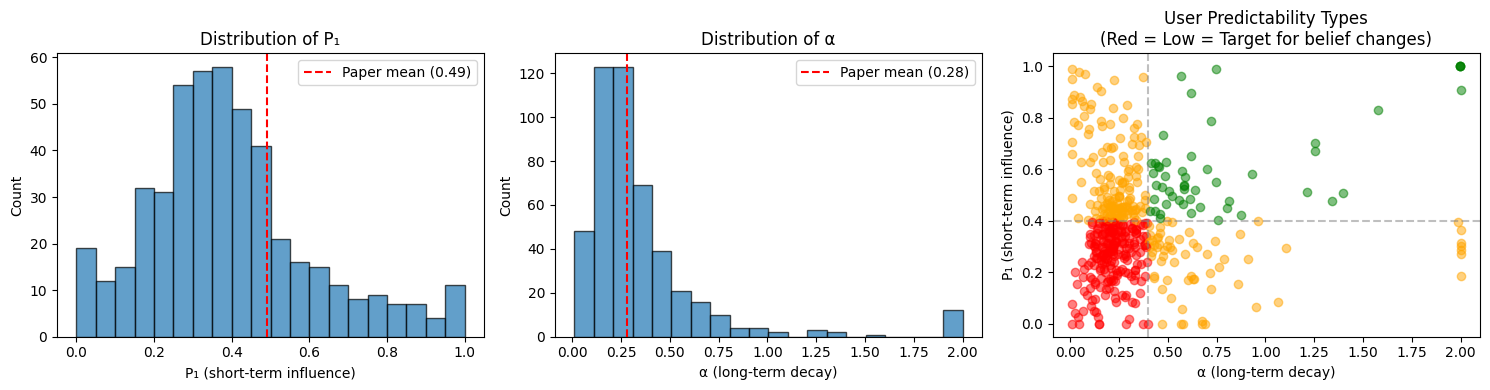

In [28]:
import matplotlib.pyplot as plt

# Plot P1 vs Alpha distribution (like Paper Figure 4)
valid_profiles = [p for p in user_profiles.values() if p.p1 is not None]

if valid_profiles:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    p1_vals = [p.p1 for p in valid_profiles]
    alpha_vals = [p.alpha for p in valid_profiles]
    
    # P1 distribution
    axes[0].hist(p1_vals, bins=20, edgecolor='black', alpha=0.7)
    axes[0].axvline(x=0.49, color='r', linestyle='--', label='Paper mean (0.49)')
    axes[0].set_xlabel('P₁ (short-term influence)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Distribution of P₁')
    axes[0].legend()
    
    # Alpha distribution
    axes[1].hist(alpha_vals, bins=20, edgecolor='black', alpha=0.7)
    axes[1].axvline(x=0.28, color='r', linestyle='--', label='Paper mean (0.28)')
    axes[1].set_xlabel('α (long-term decay)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Distribution of α')
    axes[1].legend()
    
    # Scatter plot (Paper Figure 4 style)
    colors = {'high': 'green', 'medium': 'orange', 'low': 'red', 'unknown': 'gray'}
    for p in valid_profiles:
        axes[2].scatter(p.alpha, p.p1, c=colors.get(p.predictability_type, 'gray'), alpha=0.5)
    
    axes[2].axhline(y=0.4, color='gray', linestyle='--', alpha=0.5)
    axes[2].axvline(x=0.4, color='gray', linestyle='--', alpha=0.5)
    axes[2].set_xlabel('α (long-term decay)')
    axes[2].set_ylabel('P₁ (short-term influence)')
    axes[2].set_title('User Predictability Types\n(Red = Low = Target for belief changes)')
    
    plt.tight_layout()
    plt.savefig('user_predictability_distribution.png', dpi=150)
    plt.show()
else:
    print("No valid profiles to plot")

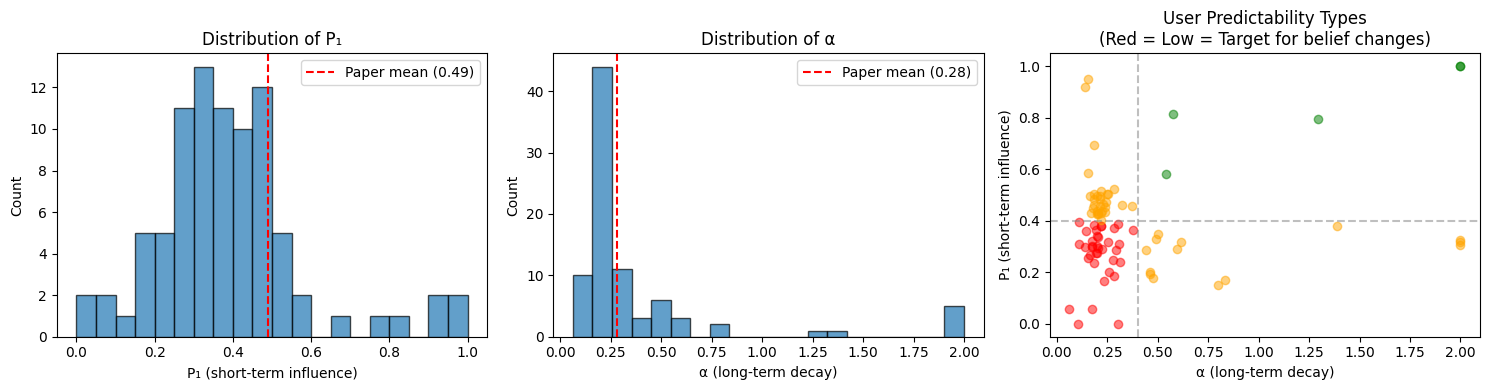

In [30]:
import matplotlib.pyplot as plt

# Plot P1 vs Alpha distribution (like Paper Figure 4)
valid_profiles = [p for p in user_profiles.values() if p.p1 is not None]

if valid_profiles:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    p1_vals = [p.p1 for p in valid_profiles]
    alpha_vals = [p.alpha for p in valid_profiles]
    
    # P1 distribution
    axes[0].hist(p1_vals, bins=20, edgecolor='black', alpha=0.7)
    axes[0].axvline(x=0.49, color='r', linestyle='--', label='Paper mean (0.49)')
    axes[0].set_xlabel('P₁ (short-term influence)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Distribution of P₁')
    axes[0].legend()
    
    # Alpha distribution
    axes[1].hist(alpha_vals, bins=20, edgecolor='black', alpha=0.7)
    axes[1].axvline(x=0.28, color='r', linestyle='--', label='Paper mean (0.28)')
    axes[1].set_xlabel('α (long-term decay)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Distribution of α')
    axes[1].legend()
    
    # Scatter plot (Paper Figure 4 style)
    colors = {'high': 'green', 'medium': 'orange', 'low': 'red', 'unknown': 'gray'}
    for p in valid_profiles:
        axes[2].scatter(p.alpha, p.p1, c=colors.get(p.predictability_type, 'gray'), alpha=0.5)
    
    axes[2].axhline(y=0.4, color='gray', linestyle='--', alpha=0.5)
    axes[2].axvline(x=0.4, color='gray', linestyle='--', alpha=0.5)
    axes[2].set_xlabel('α (long-term decay)')
    axes[2].set_ylabel('P₁ (short-term influence)')
    axes[2].set_title('User Predictability Types\n(Red = Low = Target for belief changes)')
    
    plt.tight_layout()
    plt.savefig('user_predictability_distribution.png', dpi=150)
    plt.show()
else:
    print("No valid profiles to plot")

In [33]:
candidates

[]

In [32]:
# Compare belief changes by predictability type
if candidates:
    pred_type_counts = {"high": 0, "medium": 0, "low": 0, "unknown": 0}
    for c in candidates:
        pred_type_counts[c.user_predictability or "unknown"] += 1
    
    print("\nBelief change candidates by predictability type:")
    for ptype, count in pred_type_counts.items():
        total = stats.get(f"{ptype}_predictability", 1) or 1
        rate = count / total * 100 if total > 0 else 0
        print(f"  {ptype}: {count} ({rate:.1f}% of {ptype} users)")

In [30]:
# Preview candidates
print("\n" + "="*60)
print("SAMPLE CANDIDATES")
print("="*60)

# Show one from each predictability type
for ptype in ["low", "medium", "high"]:
    type_candidates = [c for c in candidates if c.user_predictability == ptype]
    if type_candidates:
        c = type_candidates[0]
        print(f"\n--- {ptype.upper()} PREDICTABILITY USER ---")
        print(f"ID: {c.conversation_id[:30]}...")
        print(f"P₁={c.user_p1:.3f}, α={c.user_alpha:.3f}" if c.user_p1 else "P₁=N/A")
        print(f"Patterns: {c.matched_patterns[:2]}")
        print(f"Change at turns: {c.change_turn_indices}")
        print("\nConversation snippet:")
        for i in c.change_turn_indices[:1]:  # Show first change
            if i < len(c.turns):
                turn = c.turns[i]
                print(f"  [{i}] {turn.get('role', '?').upper()}: {turn.get('content', '')[:200]}...")


SAMPLE CANDIDATES

--- LOW PREDICTABILITY USER ---
ID: dd5e72c65e70260473ee1d50d59937...
P₁=0.311, α=0.326
Patterns: ['realization:\\bthat makes (?:more )?sense\\b']
Change at turns: [98]

Conversation snippet:
  [98] USER: i just had a thought ,, due to the magnets it would provide a certain amount of grinding action , because the ball/s would resist the rolling action to an extent due to the magnets trying to hold it i...

--- MEDIUM PREDICTABILITY USER ---
ID: 659f856b342977d5a1e022373d6e3b...
P₁=0.099, α=0.518
Patterns: ['realization:\\bthat makes (?:more )?sense\\b', 'realization:\\bthat makes (?:more )?sense\\b']
Change at turns: [10, 12]

Conversation snippet:
  [10] USER: I actually don't mind marriage with the right person, it's just that for me it would be simply a formality after I bonded with the right person, it's not a script I'd want to follow just to go through...

--- HIGH PREDICTABILITY USER ---
ID: 9eb0e69541371e5340988e2934413d...
P₁=0.734, α=0.477
Patterns: ['goal

## How to Use Saved Results to Filter WildChat

The saved files can be used to filter the full WildChat dataset for your experiments.

In [ ]:
# === HELPER: Load and filter WildChat by predictability type ===

def load_conv_ids(filepath: str) -> set:
    """Load conversation IDs from a text file."""
    with open(filepath, "r") as f:
        return set(line.strip() for line in f if line.strip())

def load_user_metadata(filepath: str) -> dict:
    """Load user metadata from JSONL file."""
    metadata = {}
    with open(filepath, "r") as f:
        for line in f:
            entry = json.loads(line)
            metadata[entry["conversation_hash"]] = entry
    return metadata

# Example usage:
print("=== How to filter WildChat by predictability ===")
print("""
# Load the saved IDs
predictable_ids = load_conv_ids("predictable_conv_ids.txt")
unpredictable_ids = load_conv_ids("unpredictable_conv_ids.txt")

# Load full metadata if needed
predictable_meta = load_user_metadata("predictable_users.jsonl")
unpredictable_meta = load_user_metadata("unpredictable_users.jsonl")

# Filter WildChat
from datasets import load_dataset

dataset = load_dataset("allenai/WildChat-1M", split="train")

# Get predictable conversations
predictable_convs = dataset.filter(
    lambda x: x["conversation_hash"] in predictable_ids
)

# Get unpredictable conversations (likely to show belief changes)
unpredictable_convs = dataset.filter(
    lambda x: x["conversation_hash"] in unpredictable_ids
)
""")

In [ ]:
# === Quick verification of saved files ===
import os

files_to_check = [
    "predictable_users.jsonl",
    "unpredictable_users.jsonl",
    "medium_predictability_users.jsonl",
    "predictable_conv_ids.txt",
    "unpredictable_conv_ids.txt",
    OUTPUT_FILE,
    USER_STATS_FILE
]

print("Saved files:")
for filepath in files_to_check:
    if os.path.exists(filepath):
        size = os.path.getsize(filepath)
        with open(filepath, "r") as f:
            lines = sum(1 for _ in f)
        print(f"  ✓ {filepath}: {lines} entries, {size/1024:.1f} KB")
    else:
        print(f"  ✗ {filepath}: NOT FOUND")